In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale
from sklearn import model_selection
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

pa_gs = pd.read_csv('data/pa_data.csv')

def remove_nulls(data_subset, X, y):
        # Drop rows where any of the specified X columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=X, ignore_index = True)
        # Separate the cleaned dataframe back into X and y
        X_cleaned = data_subset_cleaned[X]
        y_cleaned = data_subset_cleaned[y]
        y_cleaned = y_cleaned.squeeze()
        return X_cleaned, y_cleaned

In [37]:
X = ['dtr_annual', 'dtr_spring', 'dtr_summer', 'tmax_annual', 'prcp_annual_mm', 'prcp_growing_season_mm', 
    'prcp_spring_mm', 'latitude', 'longitude', 'elevation_m', 'dist_coast_km', 'dist_greatlakes_km', 'dist_atlantic_km',
    'oni_annual', 'nao_annual', 'nao_djf', 'pna_annual', 'amo_annual', 'sst_north_atlantic',
    'sst_gulf_stream', 'sst_gulf_mexico', 'sst_tropical_north_atl', 'pwat_eastern_us', 'pwat_southeast_us', 
    'pwat_northeast_us', 'pwat_gulf_coast', 'pwat_station', 'dewpoint_2m_eastern_us', 'soil_moisture_eastern_us',
    'cloud_cover_eastern_us', 'evaporation_eastern_us', 'dewpoint_2m_southeast_us', 'soil_moisture_southeast_us',
    'cloud_cover_southeast_us', 'evaporation_southeast_us', 'dewpoint_2m_northeast_us', 'soil_moisture_northeast_us',
    'cloud_cover_northeast_us', 'evaporation_northeast_us', 'dewpoint_2m_pennsylvania', 'soil_moisture_pennsylvania',
    'cloud_cover_pennsylvania', 'evaporation_pennsylvania', 'dewpoint_station', 'soil_moisture_station',
    'cloud_cover_station', 'evaporation_station']
y = ['growing_season_length']
X_gs, y_gs = remove_nulls(pa_gs, X, y)

In [33]:
def PCR(X, y, no_of_components):
    #defines a function that takes input variables and output variable, performs PCA analysis on them, and then
    # performs a linear regression on the first 5 principal components found in the PCA analysis.
    # required libraries: TBA

    #basic PCA setup, plotting mean squared error as number of principal components included in regression increases
    pca = PCA(n_components = no_of_components)
    X_reduced = pca.fit_transform(scale(X))
    cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
    regr = LinearRegression()
    mse=[]
    for i in np.arange(1,30):
        score = -1*model_selection.cross_val_score(regr, X_reduced[:,:i], y, cv=cv, scoring='neg_mean_squared_error').mean()
        mse.append(score)
    plt.plot(mse)
    plt.xlabel('Number of Principal Components')
    plt.ylabel('MSE')
    plt.title('Mean Square Error vs. # of Principal Components Regressed')
    plt.show()
    
    #Train-Test split, creation of regression model, and calculation of relevant accuracy metrics
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=0)

    X_reduced_train = pca.fit_transform(scale(X_train))
    X_reduced_test = pca.transform(scale(X_test))

    regr = LinearRegression()
    regr.fit(X_reduced_train, y_train)

    pred = regr.predict(X_reduced_test)
    mean_se = mean_squared_error(y_test, pred)
    r_mean_se = np.sqrt(mean_squared_error(y_test, pred))
    r_2_score = r2_score(y_test, pred)

    #arranging results for return
    coefficients = pd.DataFrame(zip(regr.coef_))
    coefficients.columns = ['coefficient']
    results = [f'MSE = {mean_se}', f'RMSE = {r_mean_se}', f'R Squared = {r_2_score}', coefficients]

    return display(results)

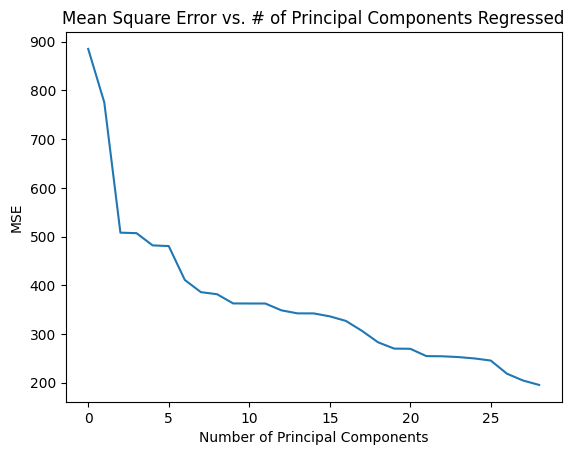

['MSE = 189.1068959912764',
 'RMSE = 13.751614304919855',
 'R Squared = 0.7969623118025864',
     coefficient
 0      3.057356
 1      4.104781
 2      7.165091
 3     -0.431546
 4     -3.063038
 5      0.915514
 6      5.873290
 7      4.208788
 8     -2.003451
 9     -3.477802
 10    -0.631969
 11     0.000361
 12    -4.132243
 13    -2.845778
 14     0.682081
 15    -3.092294
 16    -5.780300
 17     4.568556
 18    -6.533426
 19    -6.219054
 20    -1.026902
 21     6.794610
 22     2.878465
 23     1.226659
 24     4.339947
 25     6.330566
 26   -15.017830
 27     7.093035
 28    -6.604497
 29    -4.517157]

In [38]:
PCR(X_gs, y_gs, 30)

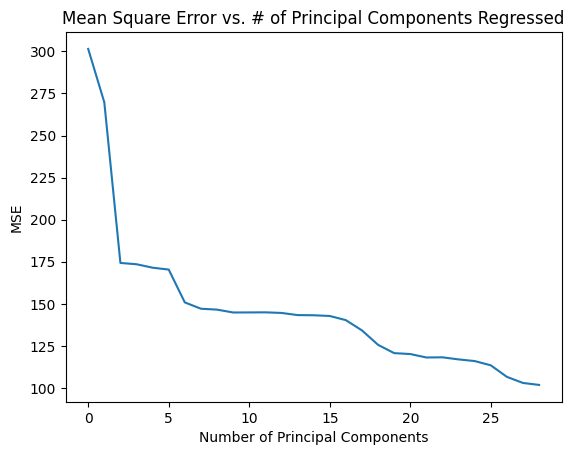

['MSE = 96.51419996438408',
 'RMSE = 9.824164084764876',
 'R Squared = 0.6907647840741566',
     coefficient
 0     -1.429854
 1     -2.178118
 2     -4.231611
 3     -0.538449
 4      0.839892
 5     -0.696287
 6     -3.135166
 7     -1.559122
 8      0.634954
 9      1.041942
 10     0.086192
 11    -0.124793
 12     0.571248
 13     1.341671
 14    -0.733939
 15     0.985546
 16     2.946912
 17    -2.365962
 18     3.896002
 19     3.909387
 20     1.106685
 21    -2.357309
 22    -1.256438
 23    -1.924545
 24    -2.136446
 25    -4.754008
 26     7.206241
 27    -4.172765
 28     3.347008
 29     1.048235]

In [41]:
y_lsf = ['last_spring_frost_doy']
X_lsf, y_lsf = remove_nulls(pa_gs, X, y_lsf)
PCR(X_lsf, y_lsf, 30)

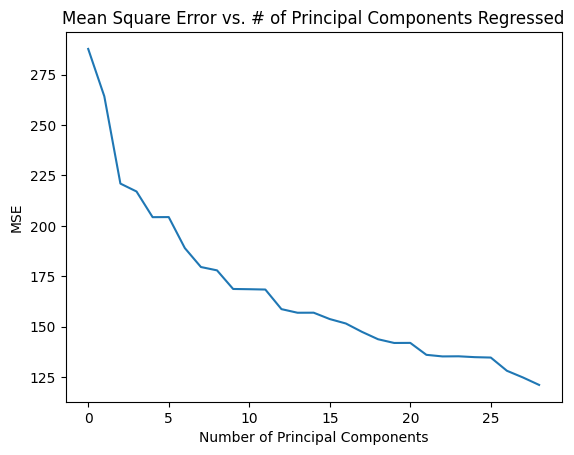

['MSE = 120.68094802333543',
 'RMSE = 10.985488064867006',
 'R Squared = 0.5953143675855329',
     coefficient
 0      1.627503
 1      1.926663
 2      2.933479
 3     -0.969995
 4     -2.223146
 5      0.219226
 6      2.738124
 7      2.649666
 8     -1.368498
 9     -2.435861
 10    -0.545777
 11    -0.124432
 12    -3.560995
 13    -1.504108
 14    -0.051859
 15    -2.106748
 16    -2.833388
 17     2.202594
 18    -2.637424
 19    -2.309666
 20     0.079783
 21     4.437301
 22     1.622027
 23    -0.697886
 24     2.203502
 25     1.576558
 26    -7.811588
 27     2.920270
 28    -3.257489
 29    -3.468922]

In [44]:
y_fff = ['first_fall_frost_doy']
X_fff, y_fff = remove_nulls(pa_gs, X, y_fff)
PCR(X_fff, y_fff, 30)